<a href="https://colab.research.google.com/github/SirLousy/LIS4693/blob/main/LIS4693/Final-Project%20/FP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Libraries

This section imports the Python libraries needed for data cleaning, text preprocessing, sentiment analysis, topic modeling, machine learning, and visualization.

In [1]:
import pandas as pd
import numpy as np
import re
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## Load and Prepare the Dataset

This section loads the TidyTuesday anime dataset, removes rows without synopsis text, resets the index, and removes duplicate anime entries using the animeID column.

In [2]:
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2019/2019-04-23/tidy_anime.csv"
df_unique = pd.read_csv(url)

df_unique = df_unique.dropna(subset=["synopsis"])
df_unique = df_unique.reset_index(drop=True)
df_unique = df_unique.drop_duplicates(subset="animeID").copy()

df_unique.head()

,animeID,name,title_english,title_japanese,title_synonyms,type,source,producers,genre,studio,...,scored_by,rank,popularity,members,favorites,synopsis,background,premiered,broadcast,related
0,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,[],TV,Original,Bandai Visual,Action,Sunrise,...,405664,26,39,795733,43460,"In the year 2071, humanity has colonized sever...",When Cowboy Bebop first aired in spring of 199...,Spring 1998,Saturdays at 01:00 (JST),"{'Adaptation': [{'mal_id': 173, 'type': 'manga..."
6,5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,"[""Cowboy Bebop: Knockin' on Heaven's Door""]",Movie,Original,Sunrise,Action,Bones,...,120243,164,449,197791,776,"Another day, another bounty—such is the life o...",NaN,NaN,NaN,"{'Parent story': [{'mal_id': 1, 'type': 'anime..."
16,6,Trigun,Trigun,トライガン,[],TV,Manga,Victor Entertainment,Action,Madhouse,...,212537,255,146,408548,10432,"Vash the Stampede is the man with a $$60,000,0...",The Japanese release by Victor Entertainment h...,Spring 1998,Thursdays at 01:15 (JST),"{'Adaptation': [{'mal_id': 703, 'type': 'manga..."
22,7,Witch Hunter Robin,Witch Hunter Robin,Witch Hunter ROBIN,['WHR'],TV,Original,Bandai Visual,Action,Sunrise,...,32837,2371,1171,79397,537,Witches are individuals with special powers li...,NaN,Summer 2002,Tuesdays at Unknown,{}
28,8,Bouken Ou Beet,Beet the Vandel Buster,冒険王ビィト,['Adventure King Beet'],TV,Manga,TV Tokyo,Adventure,Toei Animation,...,4894,3544,3704,11708,14,It is the dark century and the people are suff...,NaN,Fall 2004,Thursdays at 18:30 (JST),"{'Adaptation': [{'mal_id': 1348, 'type': 'mang..."


## Text Preprocessing

This section cleans the synopsis text by lowercasing, removing punctuation and numbers, and preparing the text for analysis.

In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z ]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

df_unique["clean_synopsis"] = df_unique["synopsis"].apply(clean_text)

## Sentiment Analysis

This section uses VADER sentiment analysis to calculate a sentiment score for each anime synopsis.

In [4]:
import nltk
nltk.download("vader_lexicon")

from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

df_unique["sentiment"] = df_unique["clean_synopsis"].apply(lambda x: sia.polarity_scores(x)["compound"])

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


## Sentiment Visualization

This section creates a histogram of sentiment scores. The visualization helps show how emotional tone is distributed across anime synopses.

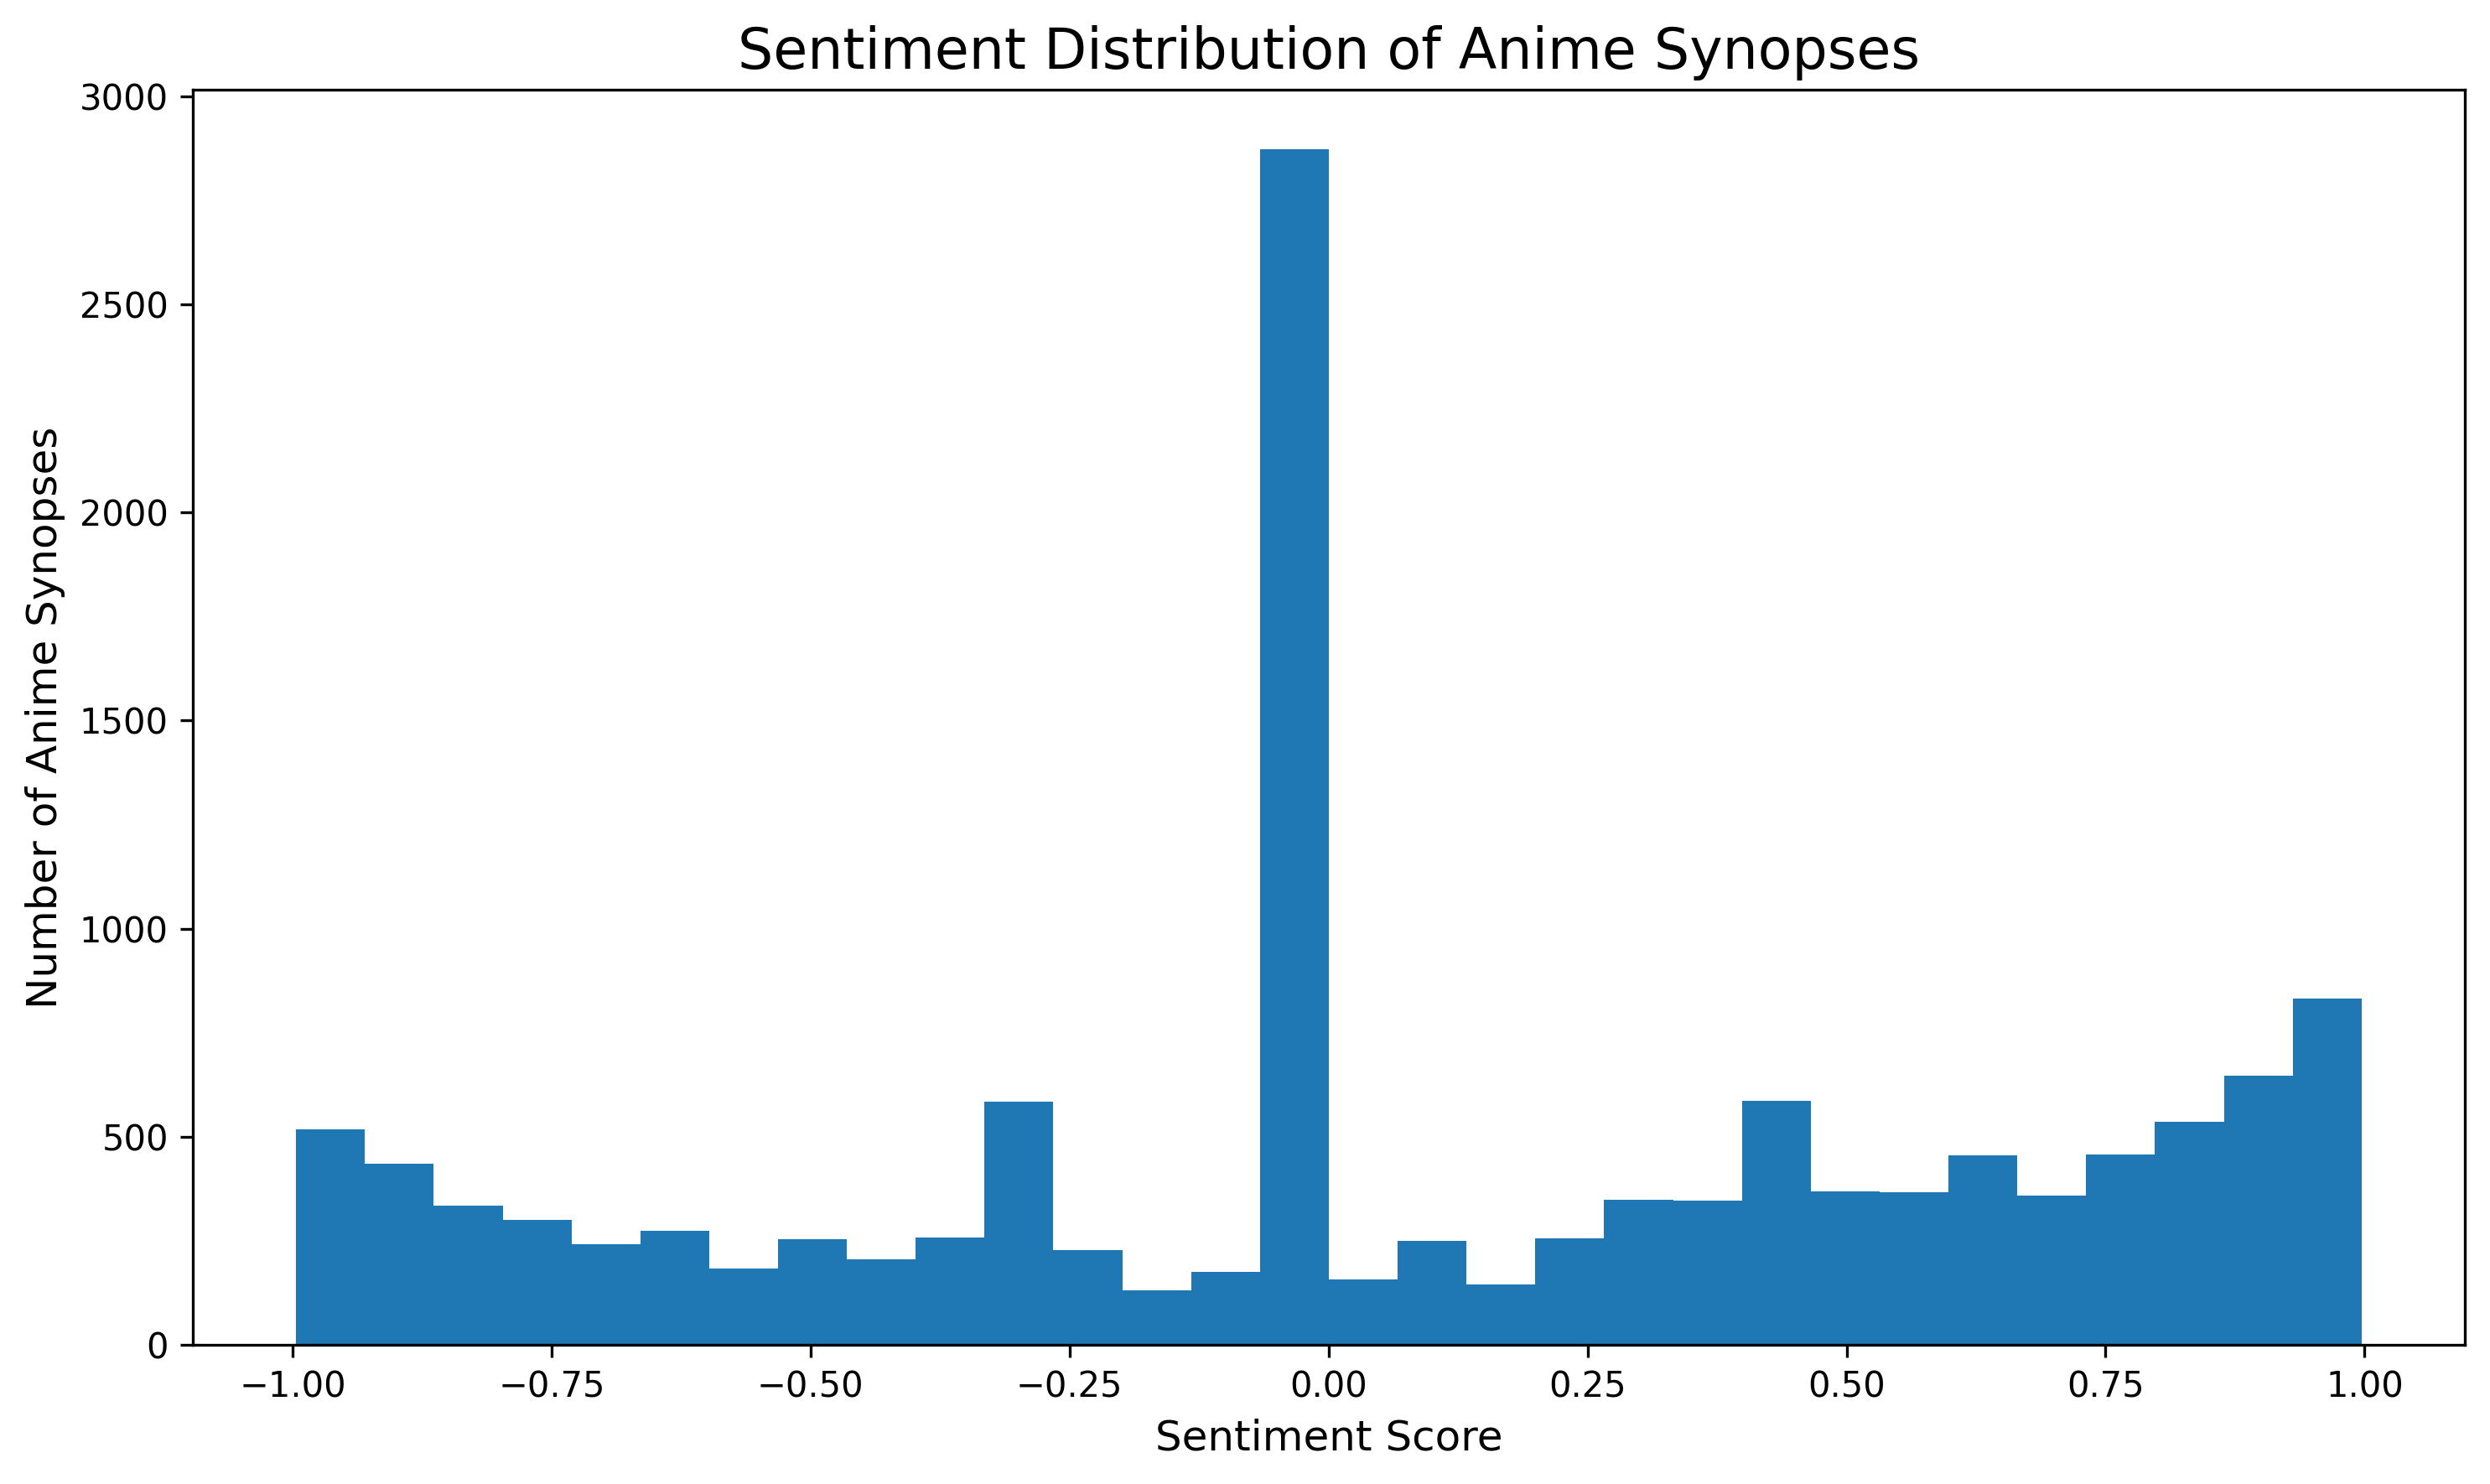

In [17]:
fig = px.histogram(
    df_unique,
    x="sentiment",
    nbins=20,
    title="Sentiment Distribution of Anime Synopses"
)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6), dpi=300)
plt.hist(df_unique["sentiment"], bins=30)
plt.title("Sentiment Distribution of Anime Synopses", fontsize=16)
plt.xlabel("Sentiment Score", fontsize=12)
plt.ylabel("Number of Anime Synopses", fontsize=12)
plt.tight_layout()
plt.savefig("sentiment_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
fig.show()

## Topic Modeling with LDA

This section uses Latent Dirichlet Allocation, also known as LDA, to identify common topics and themes in the anime synopsis text. This helps reveal repeated patterns such as action, romance, school life, fantasy, adventure, and science fiction.

In [6]:
vectorizer = CountVectorizer(stop_words="english", max_df=0.95, min_df=5)
X_topics = vectorizer.fit_transform(df_unique["clean_synopsis"])

In [7]:
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X_topics)

LatentDirichletAllocation(n_components=5, random_state=42)

In [8]:
words = vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    print(f"\nTopic {i+1}")
    print([words[j] for j in topic.argsort()[-10:]])


Topic 1
['student', 'love', 'friends', 'day', 'new', 'life', 'girl', 'high', 'source', 'school']

Topic 2
['time', 'new', 'game', 'official', 'ann', 'world', 'song', 'video', 'music', 'source']

Topic 3
['movie', 'episodes', 'manga', 'animation', 'film', 'source', 'short', 'episode', 'anime', 'series']

Topic 4
['cat', 'princess', 'life', 'magic', 'named', 'ann', 'girl', 'magical', 'world', 'source']

Topic 5
['years', 'war', 'rewrite', 'written', 'mal', 'new', 'life', 'earth', 'world', 'source']


In [9]:
X = df_unique["clean_synopsis"]
y = df_unique["type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Engineering with TF-IDF

This section converts the cleaned synopsis text into numerical features using TF-IDF. This allows the machine learning models to use text data for anime type prediction.

In [10]:
tfidf = TfidfVectorizer(max_features=5000, stop_words="english")

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

## Machine Learning Model

This section trains a Logistic Regression model to predict anime type based on the synopsis text. Logistic Regression was selected because it performed the best overall compared to the other tested models.

In [11]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [12]:
y_pred = model.predict(X_test_tfidf)

## Model Evaluation

This section evaluates the machine learning model using a classification report and confusion matrix. These outputs show the model's accuracy, precision, recall, F1 score, and where the model made correct or incorrect predictions.

In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       Movie       0.59      0.56      0.58       470
       Music       0.96      0.77      0.86       207
         ONA       0.64      0.34      0.44       259
         OVA       0.59      0.42      0.49       471
     Special       0.78      0.61      0.68       380
          TV       0.58      0.88      0.70       836

    accuracy                           0.64      2623
   macro avg       0.69      0.59      0.62      2623
weighted avg       0.65      0.64      0.62      2623



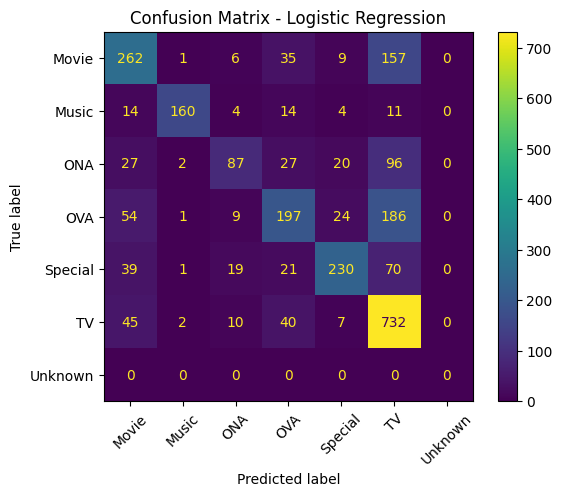

In [14]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [15]:
print(df_unique.shape)
print(df_unique.shape)

(13114, 30)
(13114, 30)
